# UAS - Clustering Mobil Bekas dengan K-Means
Notebook ini mencakup preprocessing, clustering K-Means, pelabelan cluster, dan visualisasi PCA.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## Load Dataset

In [2]:

df = pd.read_csv('/content/used_cars.csv')
print(df.shape)
df.head()


(4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Data Cleaning & Feature Engineering

In [3]:

df = df.dropna()

df['milage'] = (
    df['milage'].astype(str)
    .str.replace(' mi.', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['milage'] = pd.to_numeric(df['milage'])

df['horsepower'] = (
    df['engine']
    .str.extract(r'(\d+\.?\d*)HP')
    .astype(float)
)

df['engine_size'] = (
    df['engine']
    .str.extract(r'(\d+\.?\d*)L')
    .astype(float)
)

df['price'] = (
    df['price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['price'] = pd.to_numeric(df['price'])



In [4]:
df = df.dropna(
    subset=[
        'horsepower',
        'engine_size'
    ]
)

In [5]:
print(df.shape)

(2980, 14)


In [6]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,engine_size
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,354.0,3.5
6,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,292.0,2.0
7,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,282.0,4.4
8,Lexus,RC 350 F Sport,2021,23436,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927,311.0,3.5


In [7]:
df[['model_year','milage','horsepower','engine_size','price']].head()

,model_year,milage,horsepower,engine_size,price
0,2013,51000,300.0,3.7,10300
3,2015,88900,354.0,3.5,15500
6,2017,84000,292.0,2.0,31000
7,2001,242000,282.0,4.4,7300
8,2021,23436,311.0,3.5,41927


In [6]:
print(df['horsepower'].isna().sum())
print(df['engine_size'].isna().sum())
print(df['price'].isna().sum())

0
0
0


In [7]:
features = [
    'model_year',
    'milage',
    'horsepower',
    'engine_size',
    'price'
]

X = df[features]

print(X.isna().sum())

model_year     0
milage         0
horsepower     0
engine_size    0
price          0
dtype: int64


In [8]:
df = df[df['price'] < 1000000]

print(df.shape)

(2978, 14)


## Feature Selection & Scaling

In [9]:

features = [
    'model_year',
    'milage',
    'horsepower',
    'engine_size',
    'price'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
print(df[[
    'model_year',
    'milage',
    'horsepower',
    'engine_size',
    'price'
]].isna().sum())

print(df[[
    'model_year',
    'milage',
    'horsepower',
    'engine_size',
    'price'
]].dtypes)

model_year     0
milage         0
horsepower     0
engine_size    0
price          0
dtype: int64
model_year       int64
milage           int64
horsepower     float64
engine_size    float64
price            int64
dtype: object


## Elbow Method

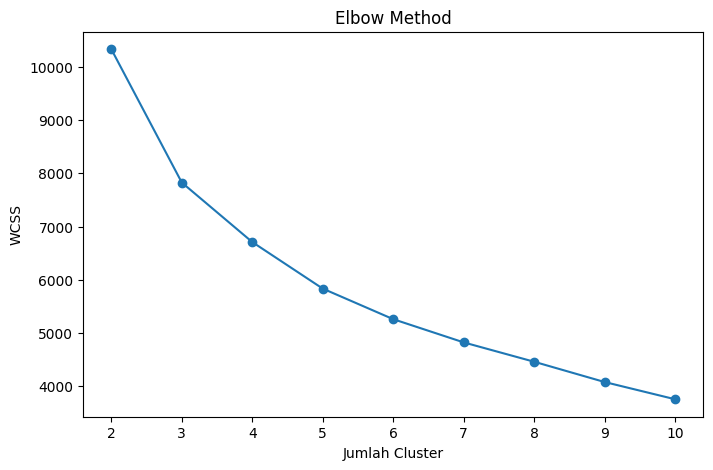

In [11]:
wcss = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

## Silhouette Score

In [12]:

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'K={k} -> {score:.4f}')


K=2 -> 0.2855
K=3 -> 0.2911
K=4 -> 0.2910
K=5 -> 0.2578
K=6 -> 0.2448
K=7 -> 0.2482
K=8 -> 0.2387
K=9 -> 0.2505
K=10 -> 0.2553


## K-Means Final (Sesuaikan k jika diperlukan)

In [13]:

k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())


Cluster
0    1170
1     898
2     677
3     233
Name: count, dtype: int64


## Ringkasan Cluster

In [14]:

cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary


,model_year,milage,horsepower,engine_size,price
Cluster,,,,,
0,2017.776068,48235.934188,282.163248,2.747949,33962.533333
1,2008.185969,128746.092428,254.678174,3.552673,12634.733853
2,2014.858198,65912.420975,429.605613,5.394092,41282.494830
3,2019.939914,15654.918455,516.738197,4.586266,126279.939914


## Pelabelan Cluster

In [15]:

cluster_labels = {
    0: 'Mobil Harian Modern',
    1: 'Mobil Bekas Ekonomis',
    2: 'Mobil Performa Tinggi',
    3: 'Mobil Premium'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

df[['brand','model','Cluster','Cluster_Label','price']].head()


,brand,model,Cluster,Cluster_Label,price
0,Ford,Utility Police Interceptor Base,0,Mobil Harian Modern,10300
3,INFINITI,Q50 Hybrid Sport,0,Mobil Harian Modern,15500
6,Audi,S3 2.0T Premium Plus,0,Mobil Harian Modern,31000
7,BMW,740 iL,1,Mobil Bekas Ekonomis,7300
8,Lexus,RC 350 F Sport,0,Mobil Harian Modern,41927


## PCA Visualization

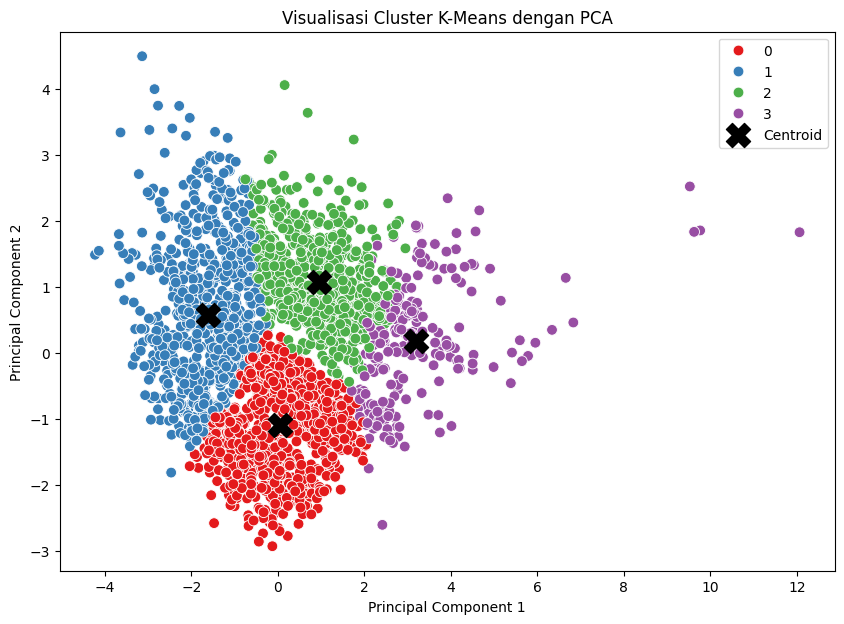

In [16]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:,0]
df['PC2'] = X_pca[:,1]

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=300,
    c='black',
    label='Centroid'
)

plt.title('Visualisasi Cluster K-Means dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


## Simpan Hasil Clustering

In [17]:

df.to_csv('used_car_clustered.csv', index=False)
print('Dataset berhasil disimpan')


Dataset berhasil disimpan


In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [19]:
dfi = pd.read_csv('used_car_clustered.csv')

print(dfi.shape)
dfi.head()

(2978, 18)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,engine_size,Cluster,Cluster_Label,PC1,PC2
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7,0,Mobil Harian Modern,-0.398500,-0.166443
1,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,354.0,3.5,0,Mobil Harian Modern,-0.292365,0.052538
2,Audi,S3 2.0T Premium Plus,2017,84000,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,31000,292.0,2.0,0,Mobil Harian Modern,-0.443888,-1.091051
3,BMW,740 iL,2001,242000,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,7300,282.0,4.4,1,Mobil Bekas Ekonomis,-2.877928,2.487437
4,Lexus,RC 350 F Sport,2021,23436,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,41927,311.0,3.5,0,Mobil Harian Modern,0.870789,-1.060005


In [20]:
features = [
    'model_year',
    'milage',
    'horsepower',
    'engine_size',
    'price'
]

X = df[features]
y = df['Cluster']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [23]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9675615212527964

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       351
           1       0.96      0.96      0.96       270
           2       0.95      0.98      0.96       203
           3       1.00      0.96      0.98        70

    accuracy                           0.97       894
   macro avg       0.97      0.97      0.97       894
weighted avg       0.97      0.97      0.97       894



In [24]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Rata-rata:", scores.mean())

Cross Validation Scores: [0.95805369 0.96979866 0.95637584 0.96302521 0.9697479 ]
Rata-rata: 0.9634002594326322


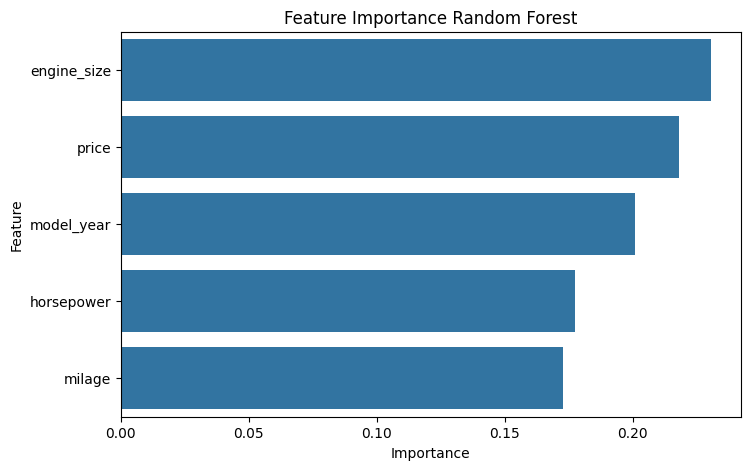

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title("Feature Importance Random Forest")
plt.show()

In [26]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameter:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameter: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9582505753322414


In [27]:
best_rf = grid.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

print("Accuracy Final:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy Final: 0.9642058165548099
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       351
           1       0.96      0.95      0.95       270
           2       0.94      0.98      0.96       203
           3       1.00      0.96      0.98        70

    accuracy                           0.96       894
   macro avg       0.97      0.96      0.97       894
weighted avg       0.96      0.96      0.96       894



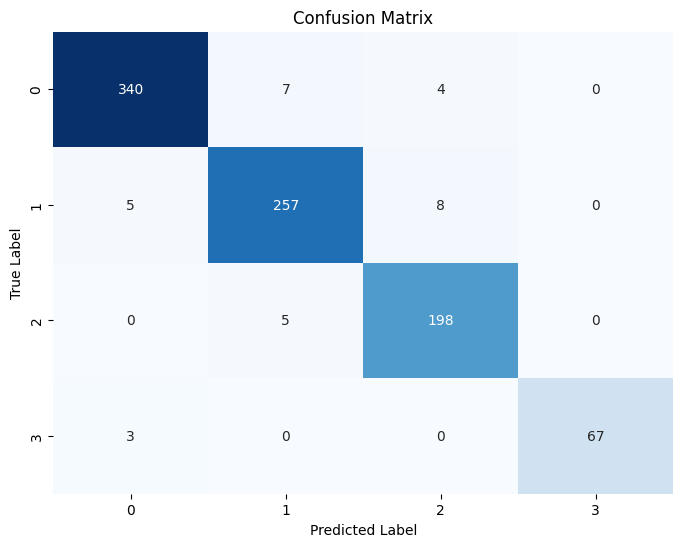

In [28]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [29]:
import joblib

joblib.dump(rf, 'rf_model.pkl')

['rf_model.pkl']

In [30]:
joblib.dump(scaler, 'scaler.pkl')   # kalau dipakai

['scaler.pkl']

In [31]:
import joblib

model = joblib.load('rf_model.pkl')

print("Model berhasil dimuat")

Model berhasil dimuat


In [32]:
sample = [[
    2019,    # model_year
    40000,   # milage
    150,     # horsepower
    1.8,     # engine_size
    85000    # price
]]

In [33]:
prediction = model.predict(sample)

print("Cluster:", prediction[0])

Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
cluster_labels = {
    0: 'Mobil Harian Modern',
    1: 'Mobil Bekas Ekonomis',
    2: 'Mobil Performa Tinggi',
    3: 'Mobil Premium'
}

In [35]:
prediction = model.predict(sample)

cluster_id = prediction[0]

print("Cluster :", cluster_id)
print("Kategori:", cluster_labels[cluster_id])

Cluster : 0
Kategori: Mobil Harian Modern


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
